# Optimization 

## Optimizitation with Skopt

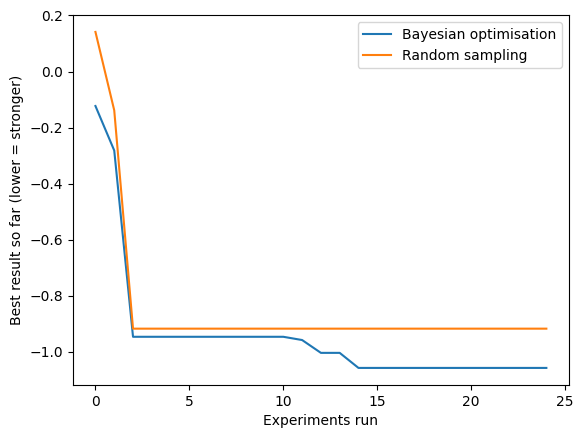

In [17]:
import numpy as np
from skopt import gp_minimize
import matplotlib.pyplot as plt

def strength(x):  # hidden "lab result": higher is better, with noise
    a, b = x
    return -(np.sin(3*a)*np.cos(2*b) + 0.5*a - (b-0.6)**2 + np.random.normal(0, 0.02))

space = [(0.0, 1.0), (0.0, 1.0)]  # ingredient ratios
n = 25
bo = gp_minimize(strength, space, n_calls=n, random_state=0)
rand = [strength(np.random.rand(2)) for _ in range(n)]

plt.plot(np.minimum.accumulate(bo.func_vals), label="Bayesian optimisation")
plt.plot(np.minimum.accumulate(rand), label="Random sampling")
plt.xlabel("Experiments run"); plt.ylabel("Best result so far (lower = stronger)")
plt.legend(); plt.savefig("bo_vs_random.png")

In [18]:
!pip install scikit-optimize


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Minimizers
from skopt import gp_minimize, forest_minimize, gbrt_minimize, dummy_minimize

# Search Space Definitions
from skopt.space import Real, Integer, Categorical

# Scikit-Learn Wrapper
from skopt import BayesSearchCV

# Diagnostic Plots
from skopt.plots import plot_convergence, plot_evaluations, plot_objective

# Manual Loop Interface
from skopt import Optimizer

# Utilities (saving/loading models)
from skopt import dump, load

In [20]:
def objective(params):
    learning_rate, max_depth = params
    # Function MUST return a scalar to minimize
    loss = (learning_rate - 0.05)**2 + (max_depth - 6)**2
    return loss

space = [
    Real(1e-4, 1e-1, prior='log-uniform', name='learning_rate'),
    Integer(2, 10, name='max_depth')
]

result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=40,            # Total budget (initial random + model-guided)
    n_initial_points=10,   # Purely random initialization steps
    acq_func="EI",         # "EI" (Expected Improvement), "LCB", "PI"
    random_state=42
)

# Accessing Results
print("Best Loss: ", result.fun)
print("Best Params:", result.x)

c:\Users\admin\anaconda3\envs\keras-course\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, np.int64(6)] before, using random point [0.0017366579555811047, np.int64(3)]
  warnings.warn(
c:\Users\admin\anaconda3\envs\keras-course\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, np.int64(6)] before, using random point [0.014669726554019597, np.int64(8)]
  warnings.warn(
c:\Users\admin\anaconda3\envs\keras-course\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, np.int64(6)] before, using random point [0.03615217358176771, np.int64(6)]
  warnings.warn(
c:\Users\admin\anaconda3\envs\keras-course\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, np.int64(6)] before, using random point [0.0014999238768064406, np.int64(9)]
  warnings.warn(
c:\

Best Loss:  3.0886895556747096e-05
Best Params: [0.055557598002441984, np.int64(6)]


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)

search_spaces = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(3, 12),
    'min_samples_split': Real(0.01, 0.2, prior='uniform'),
    'criterion': Categorical(['gini', 'entropy'])
}

opt = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=search_spaces,
    n_iter=32,            # Number of parameter settings sampled
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

opt.fit(X, y)

print("Best CV Score:", opt.best_score_)
print("Best Config:  ", opt.best_params_)

Best CV Score: 0.9607344632768361
Best Config:   OrderedDict([('criterion', 'gini'), ('max_depth', 6), ('min_samples_split', 0.019905128804105984), ('n_estimators', 189)])


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)

search_spaces = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(3, 12),
    'min_samples_split': Real(0.01, 0.2, prior='uniform'),
    'criterion': Categorical(['gini', 'entropy'])
}

opt = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=search_spaces,
    n_iter=32,            # Number of parameter settings sampled
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

opt.fit(X, y)

print("Best CV Score:", opt.best_score_)
print("Best Config:  ", opt.best_params_)

Best CV Score: 0.9607344632768361
Best Config:   OrderedDict([('criterion', 'gini'), ('max_depth', 12), ('min_samples_split', 0.029387310636351867), ('n_estimators', 295)])


In [ ]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real, Integer

X, y = load_iris(return_X_y=True)

# Define prior distributions instead of static lists
search_spaces = {
    'C': Real(1e-3, 1e2, prior='log-uniform'),
    'gamma': Real(1e-4, 1e1, prior='log-uniform'),
    'degree': Integer(1, 5),
}

opt = BayesSearchCV(
    estimator=SVC(kernel='poly'),
    search_spaces=search_spaces,
    n_iter=30,      # Number of parameter configurations to evaluate
    cv=3,           # 3-fold cross validation
    scoring='accuracy',
    random_state=42
)

# Fits surrogate, tests points, and retrains best model on full X, y
opt.fit(X, y)

print("Best Parameters:", opt.best_params_)
print("Best CV Score:  ", opt.best_score_)

## Comparing Grid search cv, RandomSearchCV and BayesSearchCV

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint

# skopt imports
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# 1. Load Data & Base Estimator
X, y = load_breast_cancer(return_X_y=True)
base_model = GradientBoostingClassifier(random_state=42)

# ==========================================
# 1. GridSearchCV (Discrete combinations)
# ==========================================
# Total combinations: 3 * 3 * 3 = 27 iterations
grid_space = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=grid_space,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X, y)
print(f"GridSearch Best Score:   {grid_search.best_score_:.4f}")

# ==========================================
# 2. RandomizedSearchCV (Statistical distributions)
# ==========================================
# Samples 25 random combinations independently
random_space = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 6),
    'learning_rate': uniform(0.01, 0.19)  # Uniform range: [0.01, 0.20]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=random_space,
    n_iter=25,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)
print(f"RandomSearch Best Score: {random_search.best_score_:.4f}")

# ==========================================
# 3. BayesSearchCV (Probabilistic priors & guided search)
# ==========================================
# Samples 25 combinations, actively updating surrogate model
bayes_space = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(2, 6),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

bayes_search = BayesSearchCV(
    estimator=base_model,
    search_spaces=bayes_space,
    n_iter=25,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X, y)
print(f"BayesSearch Best Score:  {bayes_search.best_score_:.4f}")

GridSearch Best Score:   0.9648
RandomSearch Best Score: 0.9648
BayesSearch Best Score:  0.9666
